# MA429 Summative Project (Section 5)

- **Input Dataset**: "station_hour_features.parquet"
- **Final Output**:  Demand (Inflow/Outflow) prediction result.
- **Section 5**: This notebook runs **Random Forest and XGBoost** with a **single time step** (target_outflow_t1, target_inflow_t1) on the **first 30% of time steps** (same subsample as Section 6). It runs **two lag/rolling ablations**: (1) with lag and rolling, (2) without lag and rolling (both with full heterogeneity). Train/val/test split uses (70%, 15%, 15%), metrics: MAE, RMSE, WAPE, R².

---
## 5 Demand Forecasting: Random Forest & XGBoost




### 5.0 Load station-hour feature dataset

Load the station-hour panel from Section 3–4. Set `SOURCE = "drive"` on Colab or `SOURCE = "local"` locally. **Keep only the first 30% of distinct (date, hour) time steps**.


In [27]:
import numpy as np
import pandas as pd
import os
import json
import warnings
from datetime import datetime
from typing import Dict, List, Optional, Tuple, Any
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Mount Google Drive
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass  # not in Colab

In [28]:
# Choose one: "drive" = Google Drive (Colab), "local" = local file
SOURCE = "local"

if SOURCE == "drive":
    parquet_path = "/content/drive/MyDrive/station_hour_features.parquet"
else:
    parquet_path = "station_hour_features.parquet"

df = pd.read_parquet(parquet_path)
print("Loaded shape (full):", df.shape)

# --- First 30% of time steps only (aligned with later sections) ---
_df_time = df.sort_values(["date", "hour"]).reset_index(drop=True)
uniq_time = _df_time[["date", "hour"]].drop_duplicates().sort_values(["date", "hour"]).reset_index(drop=True)
T_total = len(uniq_time)
cutoff_T = int(T_total * 0.30)
if cutoff_T < 1:
    cutoff_T = 1
uniq_time["_time_idx"] = range(T_total)
_df_time = _df_time.merge(uniq_time, on=["date", "hour"], how="left")
_df_time = _df_time[_df_time["_time_idx"] < cutoff_T].drop(columns=["_time_idx"]).reset_index(drop=True)
print(f"Using first 30% of time steps: {cutoff_T}/{T_total}")
print("Subsampled date range:", _df_time["date"].min(), "to", _df_time["date"].max())
df = _df_time
print("Loaded shape (time-subsampled 30%):", df.shape)

Loaded shape (full): (21132864, 53)
Using first 30% of time steps: 3283/10944
Subsampled date range: 2024-01-01 to 2024-05-16
Loaded shape (time-subsampled 30%): (6339473, 53)


### 5.1 Config and constants

Targets: target_outflow_t1, target_inflow_t1. **Ablation**: two feature sets (both with full heterogeneity) — with lag+rolling vs without lag and rolling. Split 70% / 15% / 15% by row order. RF/XGBoost hyperparameters as below.


In [29]:
# --- Config and constants (RF / XGBoost only) ---

# Single-step prediction target (one-step-ahead outflow; aligned with Section 6)
DEFAULT_TARGETS = ["target_outflow_t1", "target_inflow_t1"]

# Lag/rolling ablation names (each = flow+time+station + optional lag/roll + all heterogeneity)
ABLATION_ALL_HET_LAG_ROLL = "all_het_lag_rolling"     # with lag + rolling
ABLATION_ALL_HET_NO_LAG_ROLL = "all_het_no_lag_no_roll"  # without lag + rolling
# Optional names (kept for get_tree_ablation_feature_columns; not in TREE_ABLATIONS)
ABLATION_ALL_HET_ROLL_ONLY = "all_het_roll_no_lag"
ABLATION_ALL_HET_LAG_ONLY = "all_het_lag_no_roll"
# Two ablations only: with lag+rolling vs without lag/rolling
TREE_ABLATIONS = [ABLATION_ALL_HET_LAG_ROLL, ABLATION_ALL_HET_NO_LAG_ROLL]
# Primary ablation for run_config label; all ablations get plots and importance saved
PRIMARY_ABLATION_FOR_PLOTS = ABLATION_ALL_HET_LAG_ROLL
RUN_FEATURE_SET = PRIMARY_ABLATION_FOR_PLOTS

# Temporal split: train 70%, validation 15%, test 15% (by row order = time order)
SPLIT_TRAIN_RATIO = 0.70
SPLIT_VAL_RATIO = 0.15
SPLIT_TEST_RATIO = 0.15
assert abs(SPLIT_TRAIN_RATIO + SPLIT_VAL_RATIO + SPLIT_TEST_RATIO - 1.0) < 1e-9

# Legacy heterogeneity-only ablation ids
FEATURE_SET_B = "B"
ABLATION_BASE_ONLY = "base_only"
ABLATION_MEMBER_CASUAL = "base_member_casual"
ABLATION_CLUSTER = "base_cluster"
ABLATION_ALL_HET = "base_all_heterogeneity"

# Default model configs for RF and XGBoost
DEFAULT_RF_CONFIG = {
    "n_estimators": 80,
    "max_depth": 10,
    "min_samples_leaf": 4,
    "n_jobs": -1,
    "random_state": 42,
    "verbose": 1,
}
DEFAULT_XGB_CONFIG = {
    "n_estimators": 80,
    "max_depth": 10,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": 1,
}

# Output paths for logs and results
RESULTS_DIR = "section5_results"
os.makedirs(RESULTS_DIR, exist_ok=True)
LOG_DIR = os.path.join(RESULTS_DIR, "logs")
CONFIG_DIR = os.path.join(RESULTS_DIR, "configs")
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(CONFIG_DIR, exist_ok=True)

### 5.2 Feature set definitions (RF / XGBoost)

Core = flow + time + station. **Ablation**: two runs — (1) core + lag + rolling + full heterogeneity, (2) core + full heterogeneity only (no lag, no rolling).


In [30]:
# --- Feature set definitions (RF / XGBoost) ---

BASE_FLOW = ["outflow", "inflow"]
BASE_TIME = ["hour", "day_of_week", "is_weekend", "month", "sin_hour", "cos_hour"]
BASE_STATION = ["lat", "lng", "historical_mean_outflow", "historical_mean_inflow"]
HETEROGENEITY_MEMBER_CASUAL = ["member_ratio", "casual_ratio"]
HETEROGENEITY_CLUSTER = [f"cluster_{i}_ratio" for i in range(9)]
HETEROGENEITY_ALL = HETEROGENEITY_MEMBER_CASUAL + HETEROGENEITY_CLUSTER

LAG_ROLL_ABLATION_SPECS = {
    ABLATION_ALL_HET_LAG_ROLL: (True, True),
    ABLATION_ALL_HET_ROLL_ONLY: (False, True),
    ABLATION_ALL_HET_LAG_ONLY: (True, False),
    ABLATION_ALL_HET_NO_LAG_ROLL: (False, False),
}

def get_lag_rolling_columns(columns: List[str]) -> Tuple[List[str], List[str]]:
    """Extract lag and rolling feature names from dataframe columns."""
    lag_cols = [c for c in columns if c.startswith("outflow_lag") or c.startswith("inflow_lag")]
    roll_cols = [c for c in columns if "rolling" in c and ("outflow" in c or "inflow" in c)]
    return lag_cols, roll_cols

def get_tree_ablation_feature_columns(all_columns: List[str], ablation: str) -> List[str]:
    """
    Lag/rolling ablations (this notebook uses two: lag+rolling, no lag/roll): core + optional lag/rolling + full heterogeneity.
    Legacy: base_only / base_member_casual / base_cluster / base_all_heterogeneity (core+lag+roll + het subset).
    """
    base_core = [c for c in (BASE_FLOW + BASE_TIME + BASE_STATION) if c in all_columns]
    lag_cols, roll_cols = get_lag_rolling_columns(all_columns)

    if ablation in LAG_ROLL_ABLATION_SPECS:
        use_lag, use_roll = LAG_ROLL_ABLATION_SPECS[ablation]
        parts = list(base_core)
        if use_lag:
            parts += [c for c in lag_cols if c in all_columns]
        if use_roll:
            parts += [c for c in roll_cols if c in all_columns]
        feat = list(dict.fromkeys(parts))
        return feat + [c for c in HETEROGENEITY_ALL if c in all_columns]

    base = list(dict.fromkeys(base_core + [c for c in lag_cols + roll_cols if c in all_columns]))
    if ablation == ABLATION_BASE_ONLY:
        return base
    if ablation == ABLATION_MEMBER_CASUAL:
        return base + [c for c in HETEROGENEITY_MEMBER_CASUAL if c in all_columns]
    if ablation == ABLATION_CLUSTER:
        return base + [c for c in HETEROGENEITY_CLUSTER if c in all_columns]
    if ablation == ABLATION_ALL_HET:
        return base + [c for c in HETEROGENEITY_ALL if c in all_columns]
    raise ValueError(f"Unknown ablation: {ablation}")

def get_feature_columns_for_tree(df_columns: List[str], ablation: str) -> List[str]:
    """Return feature column list for tree models given ablation name."""
    return get_tree_ablation_feature_columns(df_columns, ablation)

### 5.3 Train/validation/test split

Split the sorted (date, hour) panel by row index into train (70%), validation (15%), and test (15%). No shuffling so that the test set is strictly later in time than train/val, avoiding leakage.


In [31]:
# --- Temporal split (shared by all models) ---

def temporal_train_val_test_split(
    df: pd.DataFrame,
    train_ratio: float = SPLIT_TRAIN_RATIO,
    val_ratio: float = SPLIT_VAL_RATIO,
    test_ratio: float = SPLIT_TEST_RATIO,
    time_col: Optional[str] = None,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Split dataframe by temporal order (first N% rows = train, next = val, last = test).
    Assumes df is already sorted by time (e.g. date, hour). Uses row index only to avoid
    any future information leakage.
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9
    n = len(df)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    n_test = n - n_train - n_val
    train_df = df.iloc[:n_train]
    val_df = df.iloc[n_train : n_train + n_val]
    test_df = df.iloc[n_train + n_val :]
    return train_df, val_df, test_df

def get_split_indices(
    n: int,
    train_ratio: float = SPLIT_TRAIN_RATIO,
    val_ratio: float = SPLIT_VAL_RATIO,
    test_ratio: float = SPLIT_TEST_RATIO,
) -> Tuple[slice, slice, slice]:
    """Return (train_slice, val_slice, test_slice) for use with iloc or arrays."""
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    n_test = n - n_train - n_val
    return slice(0, n_train), slice(n_train, n_train + n_val), slice(n_train + n_val, n)

### 5.4 Evaluation metrics and result aggregation

Define MAE, RMSE, WAPE, and R². `compute_metrics` returns all four; `append_result` appends a row to the results list for each model/target/split.


In [32]:
# ---  Evaluation metrics (MAE, RMSE, WAPE) ---

def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def wape(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-8) -> float:
    """Weighted Absolute Percentage Error: sum|y_true - y_pred| / sum|y_true|."""
    s_abs_diff = np.sum(np.abs(y_true - y_pred))
    s_abs_true = np.sum(np.abs(y_true)) + eps
    return float(s_abs_diff / s_abs_true)

def r2(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Coefficient of determination: 1 - SS_res/SS_tot."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot < 1e-12:
        return 0.0
    return float(1.0 - ss_res / ss_tot)

def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return {"MAE": mae(y_true, y_pred), "RMSE": rmse(y_true, y_pred), "WAPE": wape(y_true, y_pred), "R2": r2(y_true, y_pred)}

def append_result(
    results_list: List[Dict],
    model_name: str,
    target: str,
    feature_set: str,
    split: str,
    metrics: Dict[str, float],
    extra: Optional[Dict] = None,
) -> None:
    row = {"model": model_name, "target": target, "feature_set": feature_set, "split": split, **metrics}
    if extra:
        row.update(extra)
    results_list.append(row)

### 5.5 Tabular data pipeline (RF / XGBoost)

Build (X, y) arrays for train, val, and test from the split DataFrames. Returns numpy arrays for use by RF and XGBoost.


In [33]:
# --- Tabular pipeline for RF / XGBoost ---

def build_tabular_splits(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_cols: List[str],
    target_col: str,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Build X_train, y_train, X_val, y_val, X_test, y_test.
    Drops rows where target is NaN. Returns numpy arrays.
    """
    def _xy(df: pd.DataFrame):
        df = df.dropna(subset=feature_cols + [target_col])
        X = df[feature_cols].values.astype(np.float32)
        y = df[target_col].values.astype(np.float32)
        return X, y

    X_train, y_train = _xy(train_df)
    X_val, y_val = _xy(val_df)
    X_test, y_test = _xy(test_df)
    return X_train, y_train, X_val, y_val, X_test, y_test

### 5.6 Model wrappers (RF, XGBoost)

Unified train-and-predict functions for Random Forest and XGBoost. Both take (X_train, y_train, X_val, y_val, X_test) and return (val_pred, test_pred, model, feature_importance_dict). Feature importance is saved per (target, ablation) for every run.


In [34]:
# --- Model wrappers (RF, XGBoost with iteration logging) ---

def train_predict_rf(
    X_train: np.ndarray, y_train: np.ndarray,
    X_val: np.ndarray, X_test: np.ndarray,
    config: Optional[Dict] = None,
    log_callback: Optional[Any] = None,
) -> Tuple[np.ndarray, np.ndarray, Any, Optional[Dict]]:
    """Train RF, return (val_pred, test_pred, model, feature_importance_dict). Logs progress via log_callback."""
    cfg = dict(DEFAULT_RF_CONFIG)
    if config:
        cfg.update(config)
    n_est = cfg.get("n_estimators", 200)
    if log_callback:
        log_callback(f"RF: fitting {n_est} trees...")
    model = RandomForestRegressor(**cfg)
    model.fit(X_train, y_train)
    if log_callback:
        log_callback("RF: fit done.")
    imp = dict(zip(range(X_train.shape[1]), model.feature_importances_.tolist())) if hasattr(model, "feature_importances_") else None
    return model.predict(X_val), model.predict(X_test), model, imp

def train_predict_xgb(
    X_train: np.ndarray, y_train: np.ndarray,
    X_val: np.ndarray, y_val: np.ndarray,
    X_test: np.ndarray,
    config: Optional[Dict] = None,
    log_callback: Optional[Any] = None,
    verbose_eval: int = 20,
) -> Tuple[np.ndarray, np.ndarray, Any, Optional[Dict]]:
    """Train XGBoost with eval_set and iteration logging. Returns (val_pred, test_pred, model, importance_dict)."""
    cfg = dict(DEFAULT_XGB_CONFIG)
    if config:
        cfg.update(config)
    if log_callback:
        log_callback("XGBoost: starting training (verbose_eval=%s)..." % verbose_eval)
    model = xgb.XGBRegressor(**cfg)
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=verbose_eval,
    )
    if log_callback:
        log_callback("XGBoost: fit done.")
    imp = model.get_booster().get_score(importance_type="gain") if hasattr(model, "get_booster") else None
    return model.predict(X_val), model.predict(X_test), model, imp

### 5.7 Run experiments

Run RF and XGBoost for each target × each of the **two lag/rolling ablations** (with lag+rolling, without lag/rolling). Metrics in `all_results`; test predictions and feature importance saved for every ablation. Log: `section5_results/logs/training_iteration_log.txt`.


In [35]:
# ---  Run experiments: two lag/rolling ablations on first 30% time span ---
df_sorted = df.sort_values(["date", "hour"]).reset_index(drop=True)
train_df, val_df, test_df = temporal_train_val_test_split(df_sorted)

all_results = []
run_config = {
    "time_subsample": "first_30pct_timesteps",
    "split_ratios": {"train": SPLIT_TRAIN_RATIO, "val": SPLIT_VAL_RATIO, "test": SPLIT_TEST_RATIO},
    "targets": DEFAULT_TARGETS,
    "ablations": TREE_ABLATIONS,
    "primary_ablation_for_plots": PRIMARY_ABLATION_FOR_PLOTS,
    "timestamp": datetime.now().isoformat(),
}
# Precompute feature columns per ablation
cols_by_ablation = {ablation: get_feature_columns_for_tree(list(df_sorted.columns), ablation) for ablation in TREE_ABLATIONS}
# Training iteration log file
train_log_path = os.path.join(LOG_DIR, "training_iteration_log.txt")
train_log = open(train_log_path, "w")
def log_iter(msg):
    train_log.write(msg + "\n")
    train_log.flush()
log_iter("Section 5 - RF/XGBoost multi-step + ablation run started " + datetime.now().isoformat())

In [36]:
# Run RF and XGBoost for every target × each of the two ablations;
# test_predictions[(model_name, target, ablation)] = DataFrame; importance saved per (target, ablation)
test_predictions = {}
for target in DEFAULT_TARGETS:
    for ablation in TREE_ABLATIONS:
        feature_cols = cols_by_ablation[ablation]
        X_tr, y_tr, X_va, y_va, X_te, y_te = build_tabular_splits(train_df, val_df, test_df, feature_cols, target)
        log_iter("")
        log_iter(f"--- target={target} | ablation={ablation} | n_train={len(y_tr)} ---")
        # Random Forest
        log_iter(f"[RF] target={target} ablation={ablation}")
        vp, tp, model_rf, imp_rf = train_predict_rf(X_tr, y_tr, X_va, X_te, log_callback=log_iter)
        append_result(all_results, "RandomForest", target, ablation, "val", compute_metrics(y_va, vp))
        append_result(all_results, "RandomForest", target, ablation, "test", compute_metrics(y_te, tp))
        test_clean = test_df.dropna(subset=feature_cols + [target])[["station_id", "date", "hour", target]].copy()
        test_clean["pred"] = tp
        test_predictions[("RandomForest", target, ablation)] = test_clean
        if imp_rf is not None:
            with open(os.path.join(RESULTS_DIR, f"importance_rf_{target}_{ablation}.json"), "w") as f:
                json.dump(imp_rf, f, indent=2)
        # XGBoost
        log_iter(f"[XGBoost] target={target} ablation={ablation}")
        vp, tp, model_xgb, imp_xgb = train_predict_xgb(X_tr, y_tr, X_va, y_va, X_te, log_callback=log_iter, verbose_eval=0)
        append_result(all_results, "XGBoost", target, ablation, "val", compute_metrics(y_va, vp))
        append_result(all_results, "XGBoost", target, ablation, "test", compute_metrics(y_te, tp))
        test_clean = test_df.dropna(subset=feature_cols + [target])[["station_id", "date", "hour", target]].copy()
        test_clean["pred"] = tp
        test_predictions[("XGBoost", target, ablation)] = test_clean
        if imp_xgb is not None:
            with open(os.path.join(RESULTS_DIR, f"importance_xgb_{target}_{ablation}.json"), "w") as f:
                json.dump({str(k): v for k, v in imp_xgb.items()}, f, indent=2)
train_log.close()


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done  80 out of  80 | elapsed:  2.8min finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.1s
[Parallel(n_jobs=10)]: Done  80 out of  80 | elapsed:    0.3s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.1s
[Parallel(n_jobs=10)]: Done  80 out of  80 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   42.8s
[Parallel(n_jobs=-1)]: Done  80 out of  80 | elapsed:  1.9min finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0

In [37]:
# Save run config and full results (two ablations)
run_config["cols_by_ablation"] = {k: v for k, v in cols_by_ablation.items()}
with open(os.path.join(CONFIG_DIR, "run_config.json"), "w") as f:
    json.dump(run_config, f, indent=2)
results_df = pd.DataFrame(all_results)
results_df.to_csv(os.path.join(RESULTS_DIR, "baseline_results.csv"), index=False)


### 5.8 Evaluation metrics and visualization

Display the validation and test set metrics (MAE, RMSE, WAPE, R²), and plot total flow (actual vs predicted) for the first 7 days of the test period, all stations by hour.


In [38]:
# --- Full results (validation + test) ---
display(results_df)

,model,target,feature_set,split,MAE,RMSE,WAPE,R2
0,RandomForest,target_outflow_t1,all_het_lag_rolling,val,0.167761,0.613115,0.766831,0.635151
1,RandomForest,target_outflow_t1,all_het_lag_rolling,test,0.196513,0.710483,0.728562,0.640283
2,XGBoost,target_outflow_t1,all_het_lag_rolling,val,0.172974,0.605101,0.790661,0.644626
3,XGBoost,target_outflow_t1,all_het_lag_rolling,test,0.201646,0.702546,0.747590,0.648274
4,RandomForest,target_outflow_t1,all_het_no_lag_no_roll,val,0.169689,0.637342,0.775643,0.605747
5,RandomForest,target_outflow_t1,all_het_no_lag_no_roll,test,0.199106,0.744548,0.738172,0.604962
6,XGBoost,target_outflow_t1,all_het_no_lag_no_roll,val,0.175874,0.639694,0.803917,0.602832
7,XGBoost,target_outflow_t1,all_het_no_lag_no_roll,test,0.206737,0.753552,0.766465,0.595349
8,RandomForest,target_inflow_t1,all_het_lag_rolling,val,0.169610,0.640750,0.775327,0.607223
9,RandomForest,target_inflow_t1,all_het_lag_rolling,test,0.199929,0.750657,0.741194,0.601438


RandomForest (all_het_lag_rolling): All stations — total flow by hour (Actual vs Predicted)


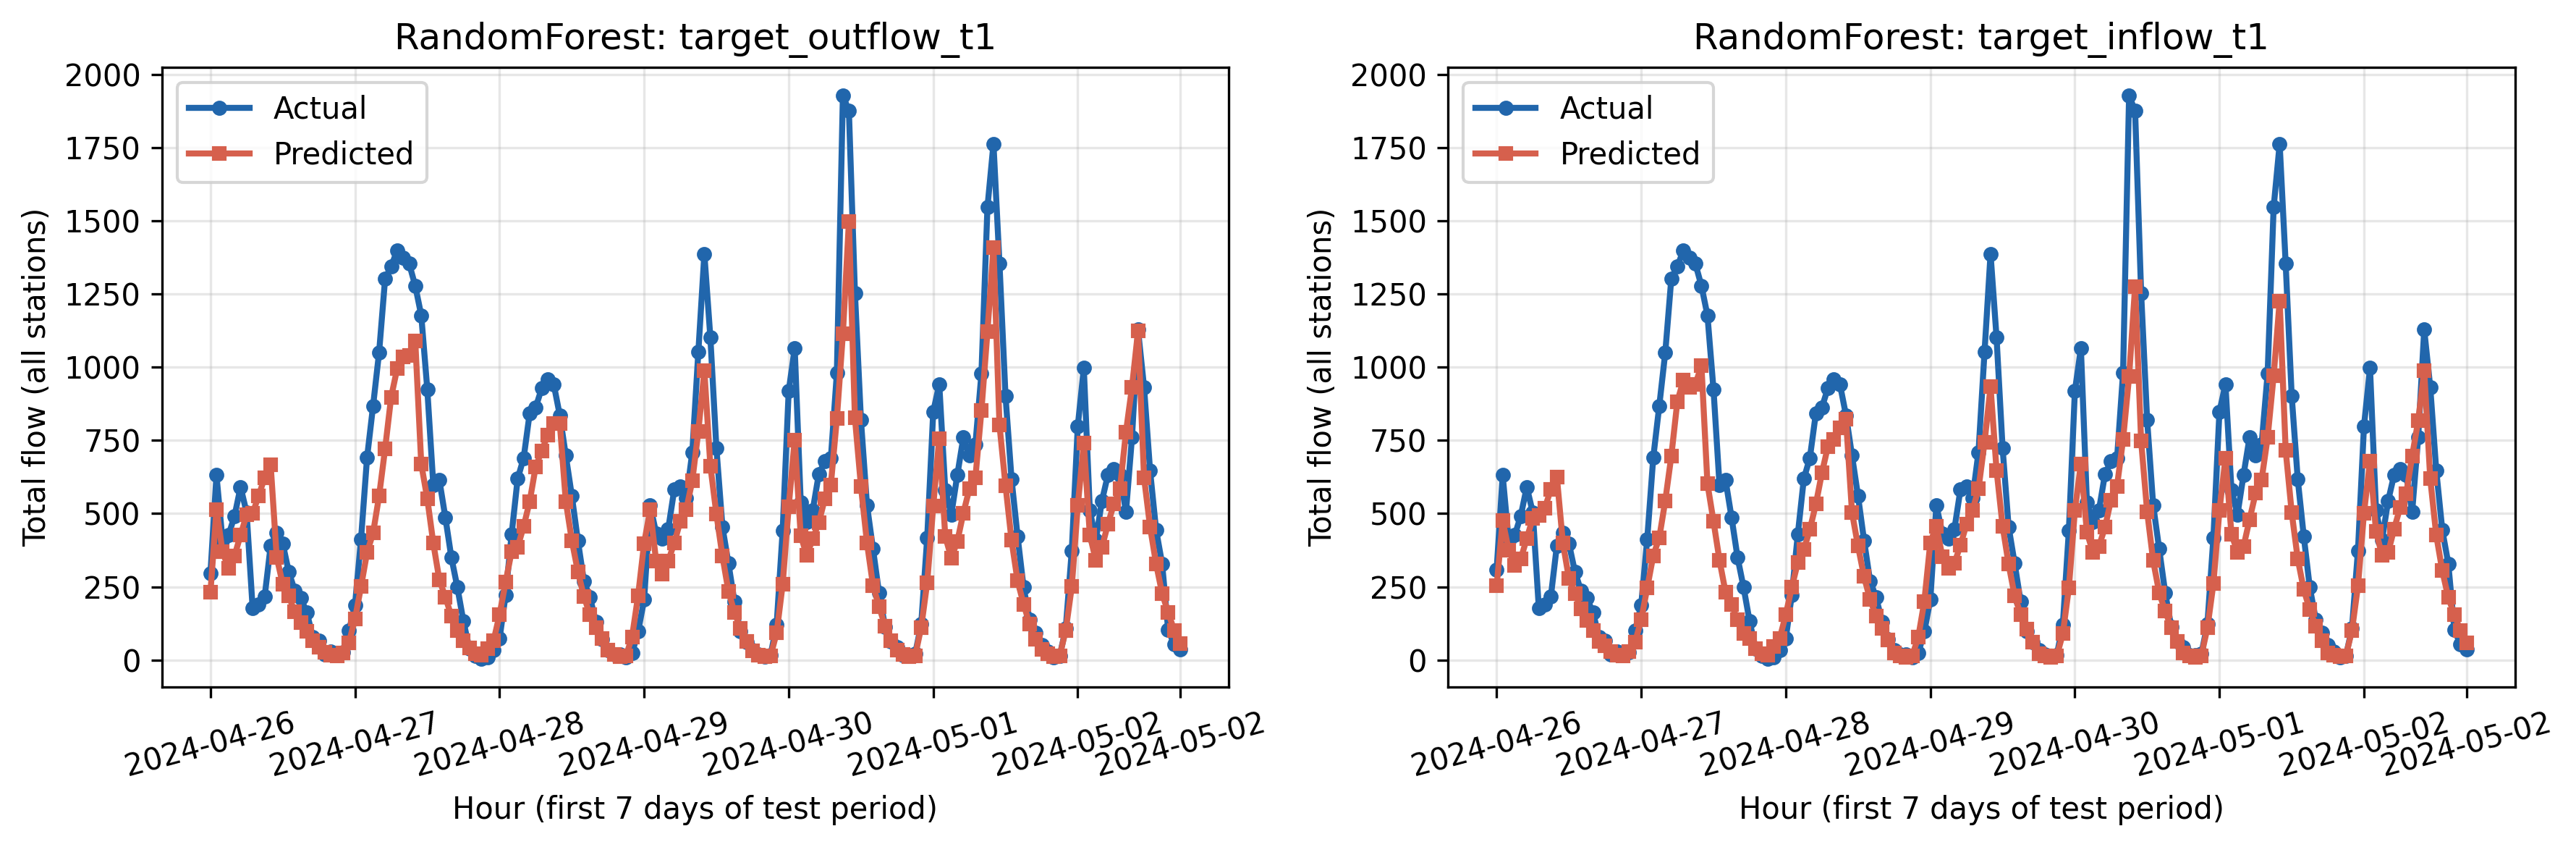

RandomForest (all_het_no_lag_no_roll): All stations — total flow by hour (Actual vs Predicted)


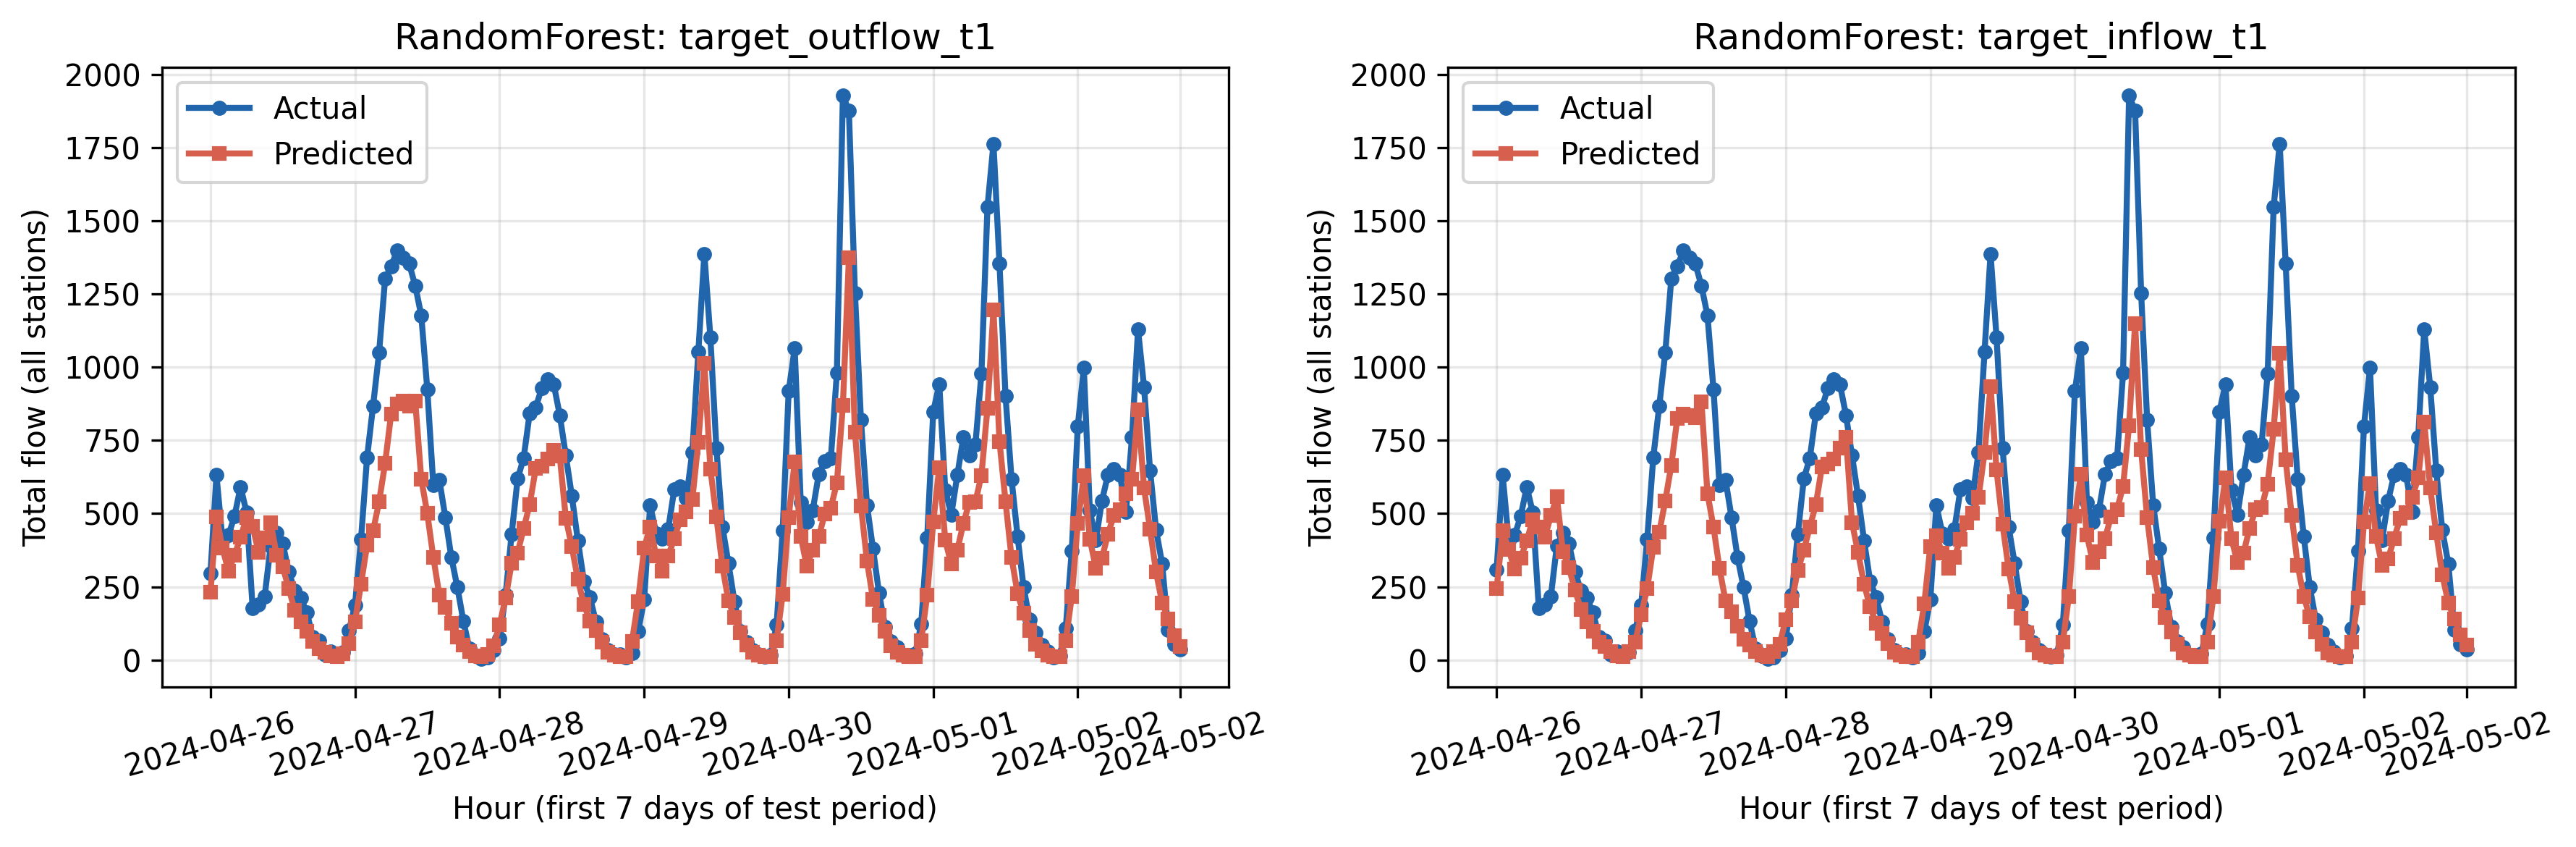

XGBoost (all_het_lag_rolling): All stations — total flow by hour (Actual vs Predicted)


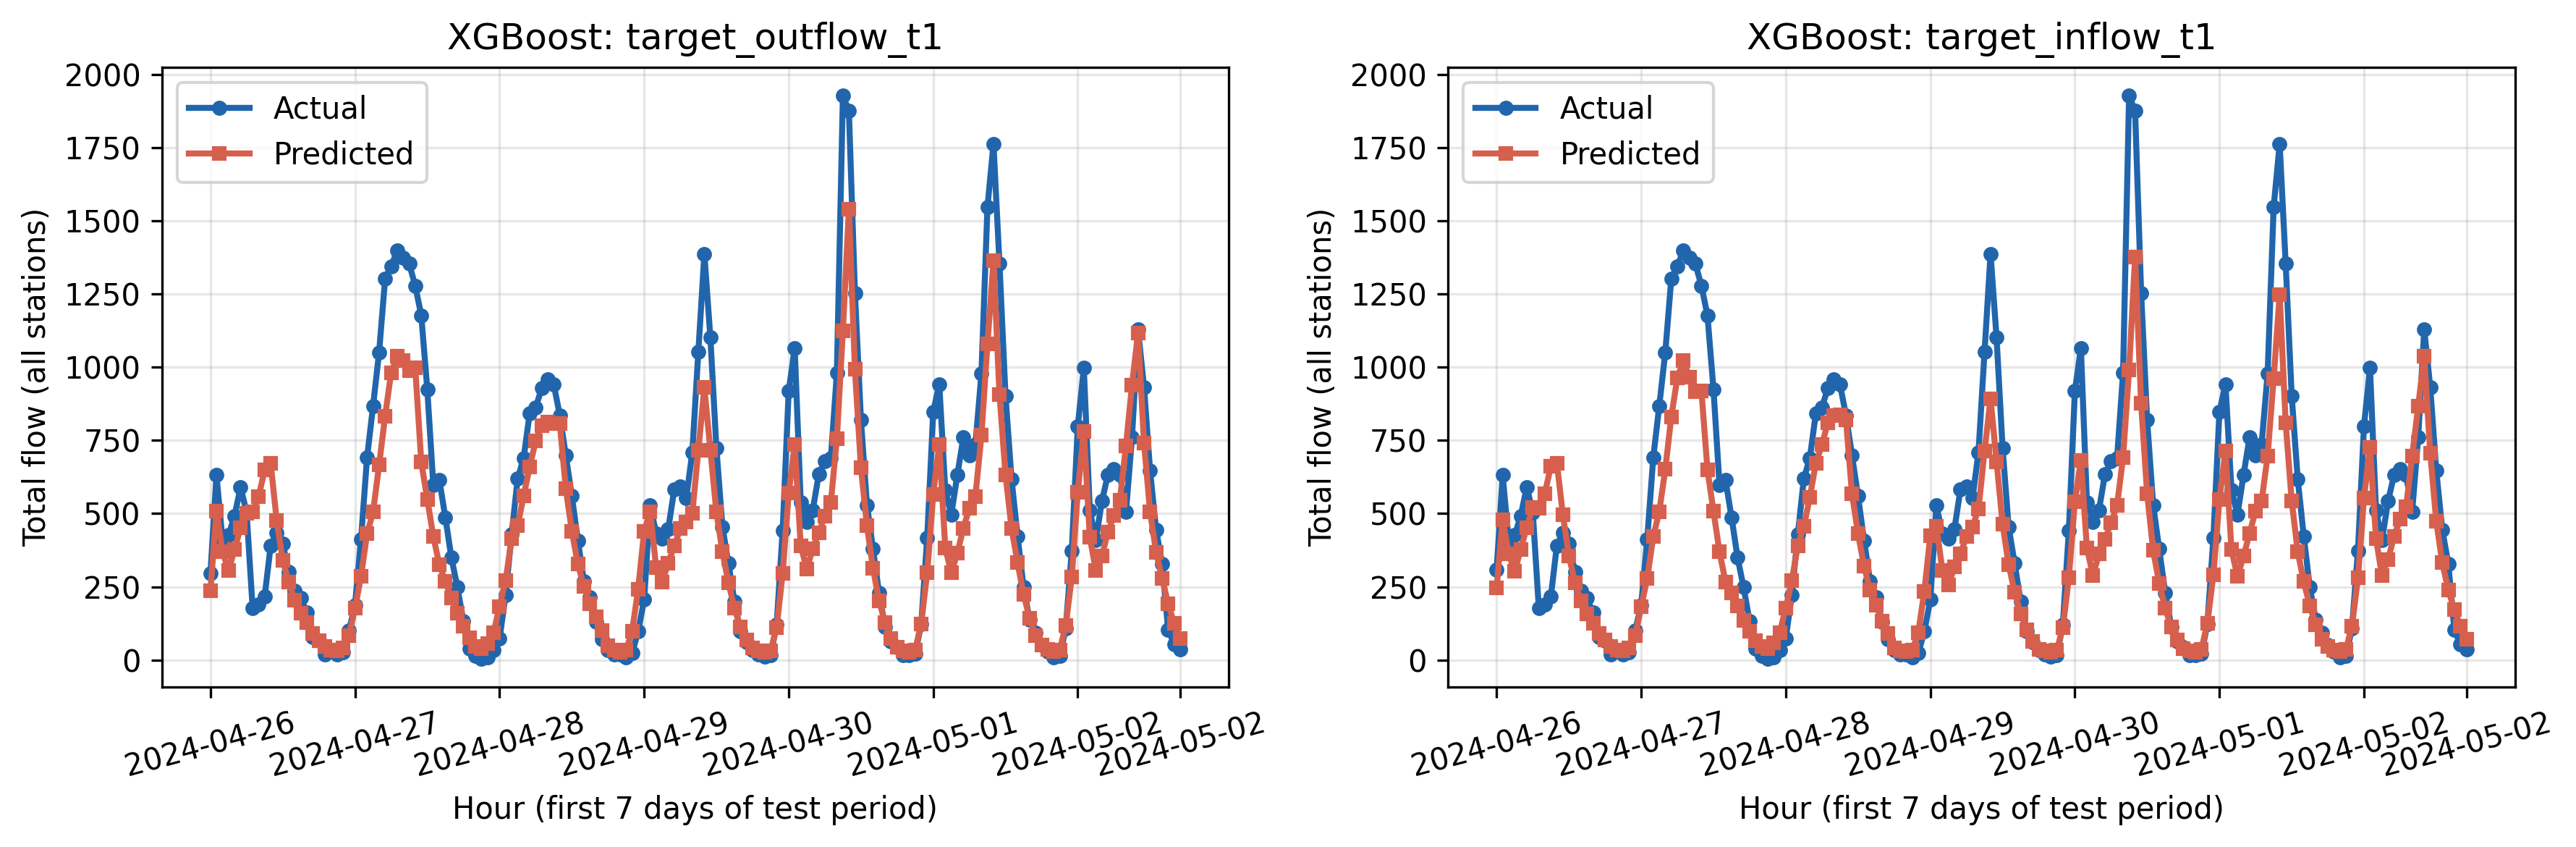

XGBoost (all_het_no_lag_no_roll): All stations — total flow by hour (Actual vs Predicted)


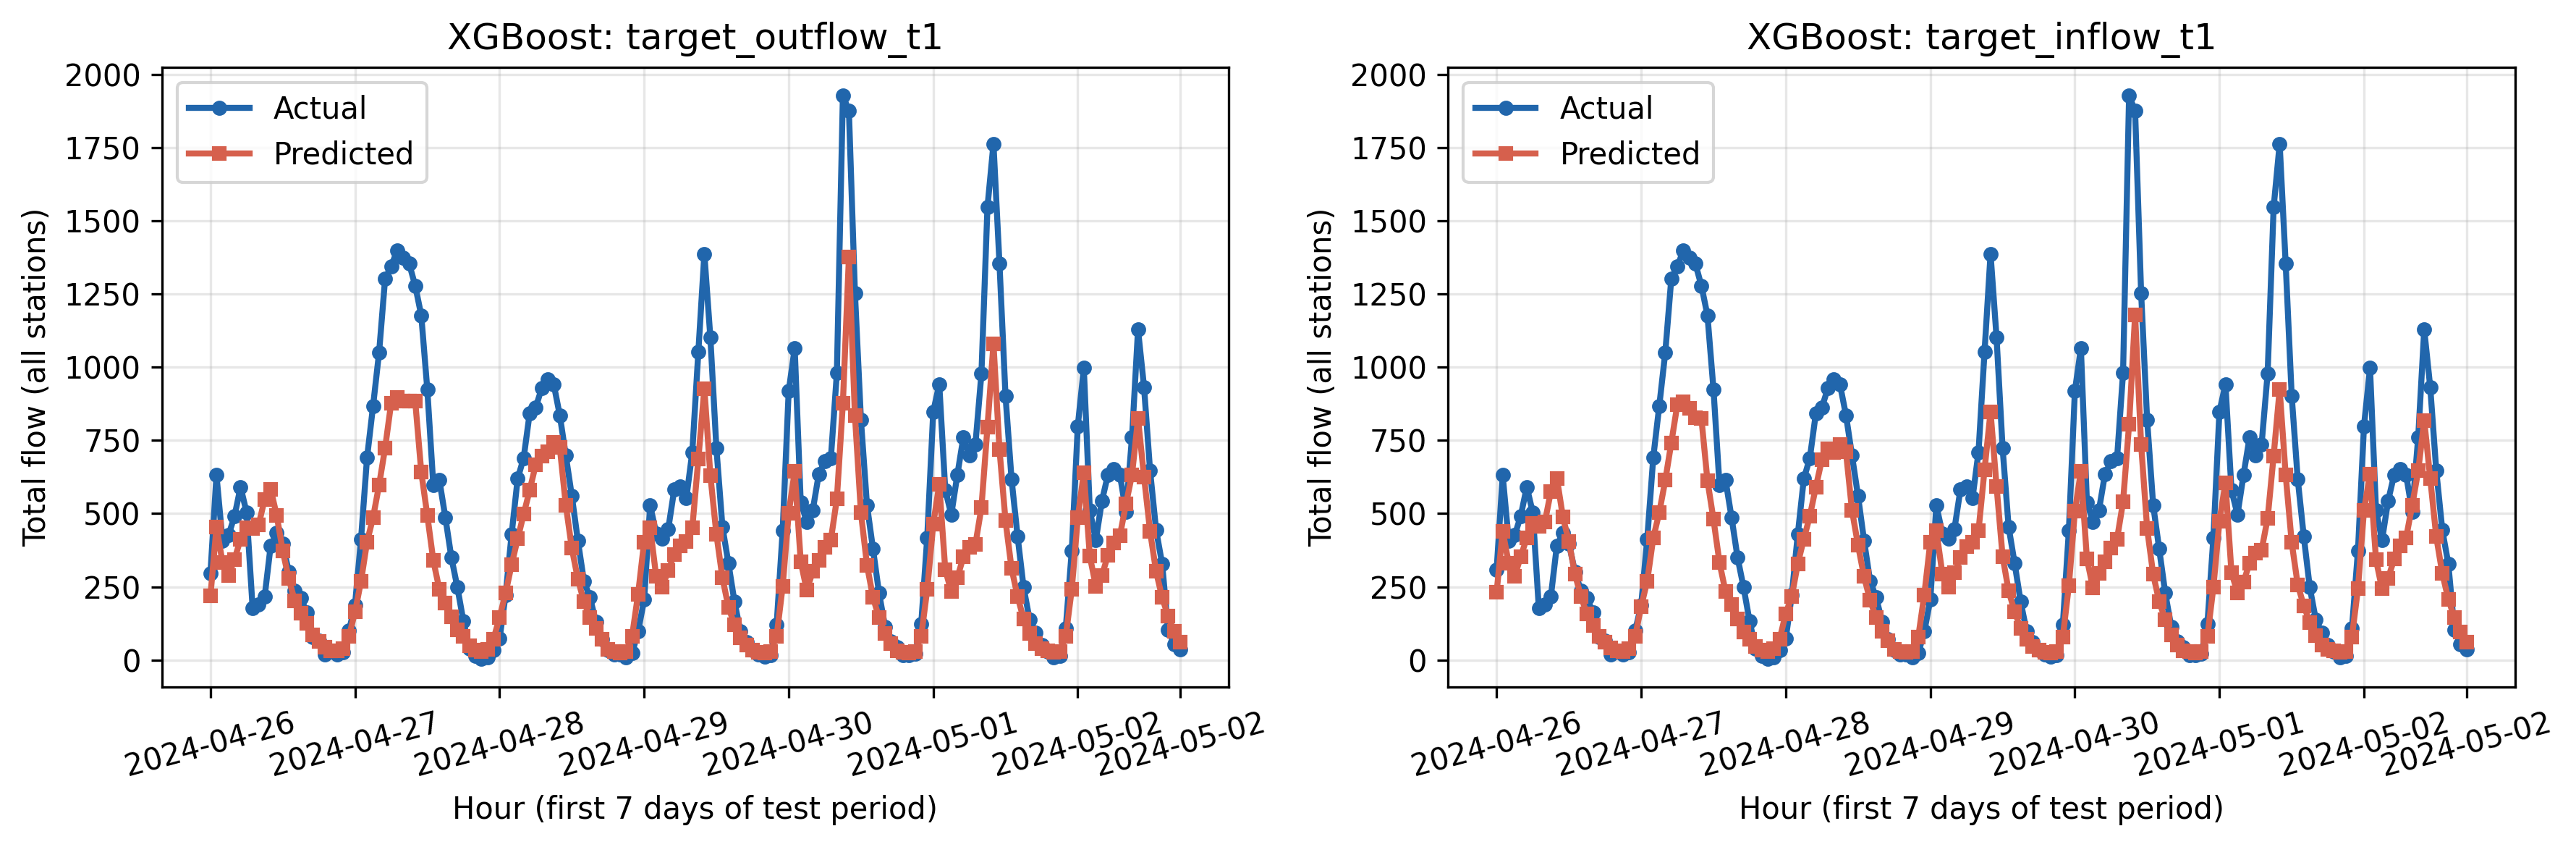

In [39]:
if "test_predictions" not in dir():
    test_predictions = {}
OUTFLOW_T1, INFLOW_T1 = "target_outflow_t1", "target_inflow_t1"
MODELS_ORDER = ["RandomForest", "XGBoost"]
TARGETS_ORDER = [OUTFLOW_T1, INFLOW_T1]
COLOR_ACTUAL, COLOR_PRED = "#2166AC", "#D6604D"

for model_name in MODELS_ORDER:
    for ablation in TREE_ABLATIONS:
        print(f"{model_name} ({ablation}): All stations — total flow by hour (Actual vs Predicted)")
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=300)
        for col, target in enumerate(TARGETS_ORDER):
            key = (model_name, target, ablation)
            ax = axes[col]
            if key not in test_predictions:
                ax.set_title(f"{model_name}: {target}")
                ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
                ax.grid(True, alpha=0.3)
                continue
            df_vis = test_predictions[key]
            actual_col = [c for c in df_vis.columns if c not in ("station_id", "date", "hour", "pred")][0]
            first_3_dates = sorted(df_vis["date"].unique())[:7]
            df_3d = df_vis[df_vis["date"].isin(first_3_dates)]
            hourly = df_3d.groupby(["date", "hour"]).agg(actual=(actual_col, "sum"), pred=("pred", "sum")).reset_index()
            hourly = hourly.sort_values(["date", "hour"]).reset_index(drop=True)
            x = np.arange(len(hourly))
            ax.plot(x, hourly["actual"], color=COLOR_ACTUAL, label="Actual", lw=2, marker="o", markersize=4)
            ax.plot(x, hourly["pred"], color=COLOR_PRED, label="Predicted", lw=2, marker="s", markersize=4)
            tick_pos = list(range(0, len(hourly), 24))
            if len(hourly) - 1 not in tick_pos and len(hourly) > 0:
                tick_pos.append(len(hourly) - 1)
            ax.set_xticks(tick_pos)
            ax.set_xticklabels([str(hourly.iloc[i]["date"]) if i < len(hourly) else "" for i in tick_pos], rotation=15)
            ax.set_xlabel("Hour (first 7 days of test period)")
            ax.set_ylabel("Total flow (all stations)")
            ax.set_title(f"{model_name}: {target}")
            ax.legend()
            ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()